In [7]:
from google.colab import drive
drive.mount('/content/drive')
print("Drive Mounted ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive Mounted ✅


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
print("Libraries Imported ✅")

Libraries Imported ✅


In [9]:
df = pd.read_csv('/content/drive/MyDrive/ifood_df.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (2205, 39)

Columns: ['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Age', 'Customer_Days', 'marital_Divorced', 'marital_Married', 'marital_Single', 'marital_Together', 'marital_Widow', 'education_2n Cycle', 'education_Basic', 'education_Graduation', 'education_Master', 'education_PhD', 'MntTotal', 'MntRegularProds', 'AcceptedCmpOverall']


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
0,58138.0,0,0,58,635,88,546,172,88,88,...,0,0,0,0,1,0,0,1529,1441,0
1,46344.0,1,1,38,11,1,6,2,1,6,...,0,0,0,0,1,0,0,21,15,0
2,71613.0,0,0,26,426,49,127,111,21,42,...,1,0,0,0,1,0,0,734,692,0
3,26646.0,1,0,26,11,4,20,10,3,5,...,1,0,0,0,1,0,0,48,43,0
4,58293.0,1,0,94,173,43,118,46,27,15,...,0,0,0,0,0,0,1,407,392,0


In [10]:
df.columns = df.columns.str.strip()
print("Missing Values:\n", df.isnull().sum())
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
print("\nCleaned Shape:", df.shape)

Missing Values:
 Income                  0
Kidhome                 0
Teenhome                0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
Age                     0
Customer_Days           0
marital_Divorced        0
marital_Married         0
marital_Single          0
marital_Together        0
marital_Widow           0
education_2n Cycle      0
education_Basic         0
education_Graduation    0
education_Master        0
education_PhD           0
MntTotal                0
MntRegularProds      

In [11]:
print("Average Income:", df['Income'].mean())
print("Max Income:", df['Income'].max())
print("Min Income:", df['Income'].min())
print("\nFull Statistics:")
df.describe()

Average Income: 51687.2587827808
Max Income: 113734.0
Min Income: 1730.0

Full Statistics:


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,marital_Together,marital_Widow,education_2n Cycle,education_Basic,education_Graduation,education_Master,education_PhD,MntTotal,MntRegularProds,AcceptedCmpOverall
count,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,...,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000,2021.000000
mean,51687.258783,0.443345,0.509649,48.880752,306.492331,26.364671,166.059871,37.603662,27.268679,43.921821,...,0.251856,0.034636,0.090549,0.024245,0.502227,0.165760,0.217219,563.789213,519.867392,0.302326
std,20713.046401,0.536196,0.546393,28.950917,337.603877,39.776518,219.869126,54.892196,41.575454,51.678211,...,0.434186,0.182902,0.287038,0.153848,0.500119,0.371957,0.412455,576.775749,554.797857,0.680812
min,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,-283.000000,0.000000
25%,35416.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,55.000000,42.000000,0.000000
50%,51412.000000,0.000000,0.000000,49.000000,178.000000,8.000000,68.000000,12.000000,8.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,343.000000,288.000000,0.000000
75%,68274.000000,1.000000,1.000000,74.000000,507.000000,33.000000,230.000000,50.000000,34.000000,56.000000,...,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,964.000000,883.000000,0.000000
max,113734.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2491.000000,2458.000000,4.000000


In [12]:
features = ['Income', 'Kidhome', 'Teenhome',
            'AcceptedCmp1', 'AcceptedCmp2',
            'AcceptedCmp3', 'AcceptedCmp4',
            'AcceptedCmp5', 'Response']
df_cluster = df[features].copy()
print("Features Selected ✅")
df_cluster.head()

Features Selected ✅


,Income,Kidhome,Teenhome,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response
0,58138.0,0,0,0,0,0,0,0,1
1,46344.0,1,1,0,0,0,0,0,0
2,71613.0,0,0,0,0,0,0,0,0
3,26646.0,1,0,0,0,0,0,0,0
4,58293.0,1,0,0,0,0,0,0,0


In [13]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cluster)
print("Data Scaled ✅")

Data Scaled ✅


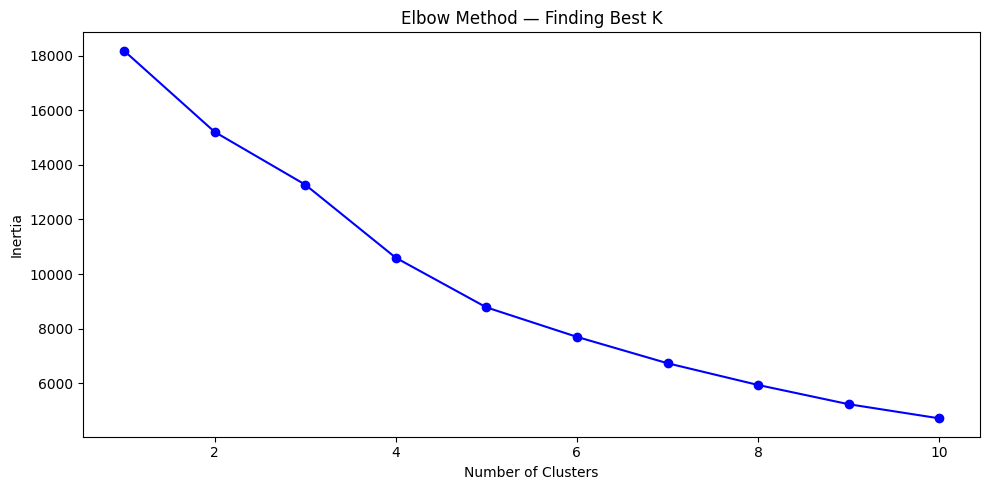

In [14]:
inertia = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10,5))
plt.plot(K_range, inertia, marker='o', color='blue')
plt.title('Elbow Method — Finding Best K')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

In [15]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(df_scaled)
print("Clusters Assigned ✅")
print(df['Cluster'].value_counts())

Clusters Assigned ✅
Cluster
1    886
0    826
3    175
2    134
Name: count, dtype: int64


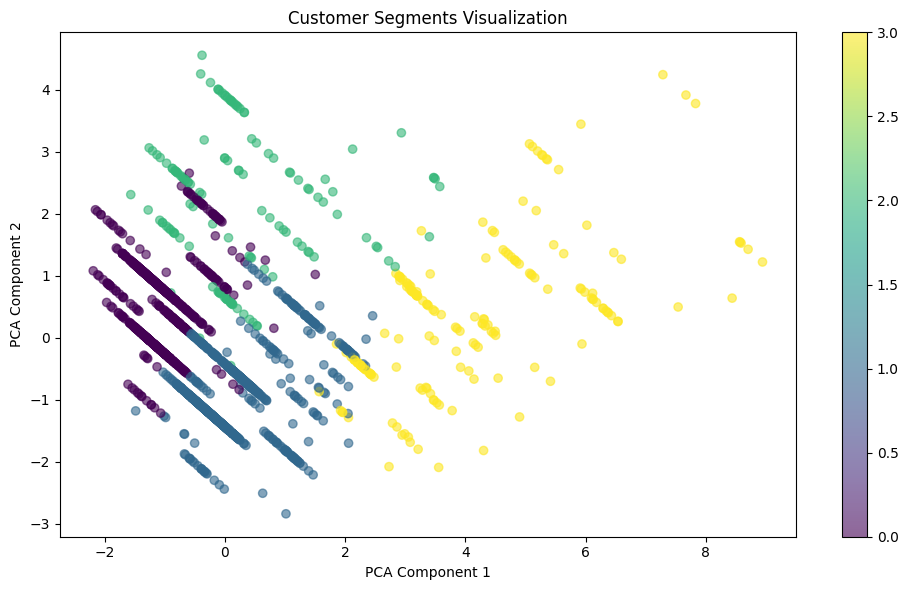

In [16]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_scaled)

plt.figure(figsize=(10,6))
scatter = plt.scatter(pca_result[:,0], pca_result[:,1],
                     c=df['Cluster'], cmap='viridis',
                     alpha=0.6)
plt.colorbar(scatter)
plt.title('Customer Segments Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.show()

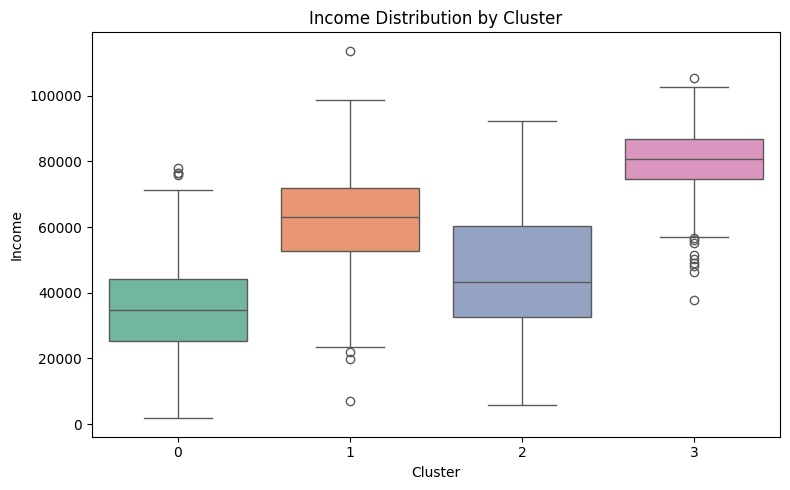

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Cluster', y='Income',
            data=df, palette='Set2')
plt.title('Income Distribution by Cluster')
plt.tight_layout()
plt.show()

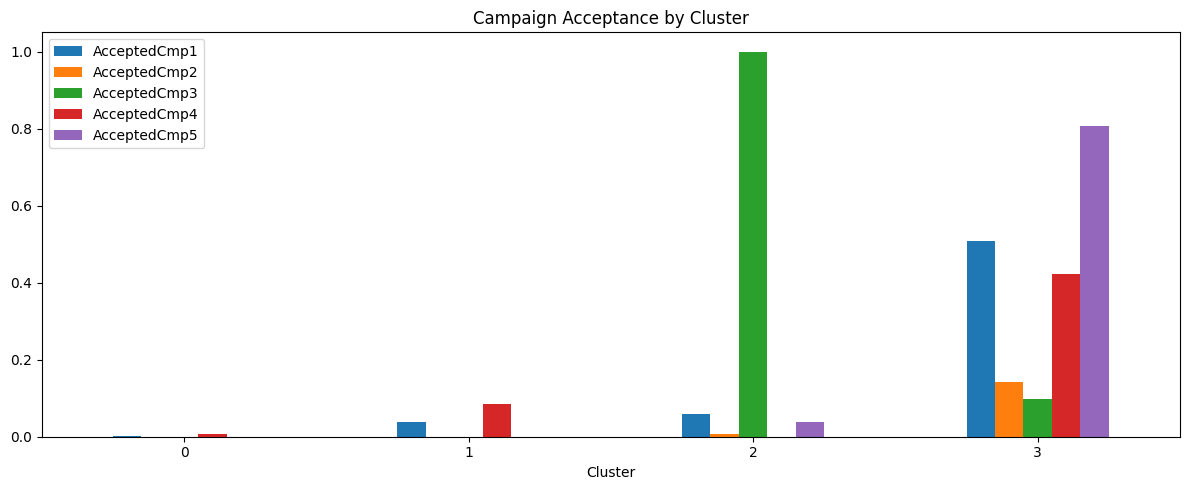

In [18]:
campaign_cols = ['AcceptedCmp1','AcceptedCmp2',
                 'AcceptedCmp3','AcceptedCmp4',
                 'AcceptedCmp5']
df.groupby('Cluster')[campaign_cols].mean().plot(
    kind='bar', figsize=(12,5),
    title='Campaign Acceptance by Cluster')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
features = ['Income', 'Kidhome', 'Teenhome',
            'AcceptedCmp1', 'AcceptedCmp2',
            'AcceptedCmp3', 'AcceptedCmp4',
            'AcceptedCmp5', 'Response']
cluster_analysis = df.groupby('Cluster')[features].mean()
print("Cluster Analysis:\n")
print(cluster_analysis)

Cluster Analysis:

               Income   Kidhome  Teenhome  AcceptedCmp1  AcceptedCmp2  \
Cluster                                                                 
0        35299.416465  0.957627  0.420097      0.002421      0.000000   
1        62154.873589  0.033860  0.662528      0.038375      0.000000   
2        46877.395522  0.522388  0.455224      0.059701      0.007463   
3        79724.817143  0.028571  0.200000      0.508571      0.142857   

         AcceptedCmp3  AcceptedCmp4  AcceptedCmp5  Response  
Cluster                                                      
0            0.000000      0.006053      0.000000  0.087167  
1            0.000000      0.085779      0.000000  0.086907  
2            1.000000      0.000000      0.037313  0.425373  
3            0.097143      0.422857      0.805714  0.600000  


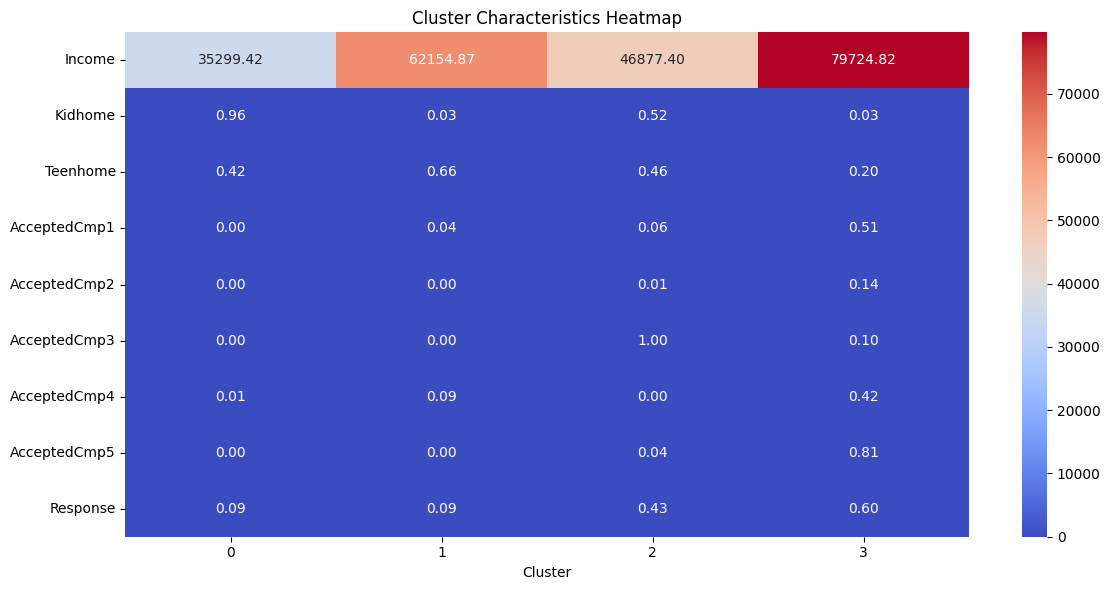

In [20]:
plt.figure(figsize=(12,6))
sns.heatmap(cluster_analysis.T,
            annot=True, cmap='coolwarm',
            fmt='.2f')
plt.title('Cluster Characteristics Heatmap')
plt.tight_layout()
plt.show()

## Recommendations - Customer Segmentation

1. Cluster 0 — Low Income, No Kids
   → Target with budget-friendly offers
   → Send discount coupons

2. Cluster 1 — High Income, Accepted Campaigns
   → Target with premium products
   → Loyalty rewards program

3. Cluster 2 — Medium Income, Has Kids
   → Target with family deals
   → Back to school promotions

4. Cluster 3 — Low Campaign Response
   → Re-engage with personalized offers
   → Send reminder emails

Key Finding: Income is the strongest factor
in determining customer segments!